# Enriched Music Charts Analysis



**Week:** 2026-W15 | **Analysis Date:** 2026-04-06


## 1. Introduction

Welcome back, chart watchers! This week, we've crunched the numbers on a truly global playlist of 100 tracks, spanning 25 countries and 16 distinct genres, proving once again that great music knows no borders. With over 1.4 billion views and 286 million likes lighting up the board, the sheer scale of fan engagement is staggering. We're diving deep to uncover which nations are setting the trends, which genres are sparking the most passionate reactions, and how strategic collaborations are climbing the ranks. Get ready to see the story behind the stats.

## 2. Setup and Data Loading

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import sqlite3
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display in notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

YT_RED = '#FF0000'
YT_RED_DARK = '#CC0000'
YT_BG = '#FFFFFF'
YT_SURFACE = '#F9F9F9'
YT_TEXT = '#0F0F0F'
YT_GRAY = '#606060'
YT_GRID = '#E5E5E5'

def format_number(x):
    if pd.isna(x): return x
    if x >= 1_000_000_000: return f"{x/1_000_000_000:.1f}B"
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

# Load data - using relative path from notebook directory to repo root
# Notebook is in Notebook_EN/weekly/ or Notebook_ES/weekly/, database is in charts_archive/3_enrich-chart-data/
db_path = "../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W15_enriched.db"
print(f"Loading data from: {db_path}")
conn = sqlite3.connect(db_path)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables found: {[t[0] for t in tables]}")

if not tables:
    raise ValueError(f"No tables found in database: {db_path}")

table_name = 'enriched_songs'
if (table_name,) not in tables:
    table_name = tables[0][0]
    print(f"Using table: {table_name}")

df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df['upload_quarter'] = df['upload_date'].dt.quarter
df['engagement'] = np.where(df['views'] > 0, (df['likes'] / df['views'] * 100).round(2), 0.0)

print(f"Loaded {len(df)} songs, {df.shape[1]} columns")
df.head()


Loading data from: ../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W15_enriched.db
Tables found: ['enriched_songs', 'sqlite_sequence']
Loaded 100 songs, 28 columns


,id,rank,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,1,BTS,SWIM,2,52589269,https://www.youtube.com/watch?v=b4iVv91Z6lY,245,4:05,2026-03-20,...,0,1,0,South Korea,K-Pop/K-Rock,1/1,,2026-04-06 14:55:40,1.0,11.79
1,2,2,Banjaare,Bairan,4,43671738,https://www.youtube.com/watch?v=oafxkMv4xnc,151,2:31,2026-02-13,...,0,1,0,India,Indian Pop,1/1,,2026-04-06 14:55:41,1.0,2.37
2,3,3,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,Shararat,16,39303998,https://www.youtube.com/watch?v=YyepU5ztLf4,229,3:49,2025-12-09,...,0,3,0,India,Indian Pop,3/3,,2026-04-06 14:55:41,4.0,4.70
3,4,4,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,Gehra Hua,18,37965461,https://www.youtube.com/watch?v=GX9x62kFsVU,231,3:51,2025-11-28,...,0,4,0,India,Indian Pop,4/4,,2026-04-06 14:55:41,4.0,3.35
4,5,5,Shashwat Sachdev & Satinder Sartaaj & Jasmine ...,Jaiye Sajana,2,36110584,https://www.youtube.com/watch?v=F2m4HPLvj-4,152,2:32,2026-03-29,...,0,3,0,India,Indian Pop,3/3,,2026-04-06 14:55:41,1.0,0.59


## 3. Data Preview

In [2]:
df.head()

,id,rank,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,1,BTS,SWIM,2,52589269,https://www.youtube.com/watch?v=b4iVv91Z6lY,245,4:05,2026-03-20,...,0,1,0,South Korea,K-Pop/K-Rock,1/1,,2026-04-06 14:55:40,1.0,11.79
1,2,2,Banjaare,Bairan,4,43671738,https://www.youtube.com/watch?v=oafxkMv4xnc,151,2:31,2026-02-13,...,0,1,0,India,Indian Pop,1/1,,2026-04-06 14:55:41,1.0,2.37
2,3,3,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,Shararat,16,39303998,https://www.youtube.com/watch?v=YyepU5ztLf4,229,3:49,2025-12-09,...,0,3,0,India,Indian Pop,3/3,,2026-04-06 14:55:41,4.0,4.70
3,4,4,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,Gehra Hua,18,37965461,https://www.youtube.com/watch?v=GX9x62kFsVU,231,3:51,2025-11-28,...,0,4,0,India,Indian Pop,4/4,,2026-04-06 14:55:41,4.0,3.35
4,5,5,Shashwat Sachdev & Satinder Sartaaj & Jasmine ...,Jaiye Sajana,2,36110584,https://www.youtube.com/watch?v=F2m4HPLvj-4,152,2:32,2026-03-29,...,0,3,0,India,Indian Pop,3/3,,2026-04-06 14:55:41,1.0,0.59


## 4. General Statistics

In [3]:

stats = pd.DataFrame({
    'Total Songs': [100],
    'Unique Countries': [25],
    'Unique Genres': [16],
    'Total Views': [1411376244],
    'Total Likes': [286794387],
    'Total Comments': [12282904],
    'Avg Views': [14113762],
    'Avg Likes': [2867944]
})

print("GENERAL STATISTICS")
display(stats)


GENERAL STATISTICS


,Total Songs,Unique Countries,Unique Genres,Total Views,Total Likes,Total Comments,Avg Views,Avg Likes
0,100,25,16,1411376244,286794387,12282904,14113762,2867944


This dataset reflects a highly curated, globally resonant music collection. With 25 countries and 16 genres represented, the content demonstrates significant geographic and stylistic diversity, suggesting a deliberate strategy for broad international appeal rather than a niche focus.

The exceptionally high average views (14.1M) and likes (2.87M) indicate massive reach and strong audience engagement. The like-to-view ratio of approximately 20.3% is well above typical platform averages, pointing to a deeply connected and enthusiastic fanbase.

Key market insights include the viability of cross-cultural content when it achieves high production value and emotional resonance. The data underscores that in today's fragmented landscape, success is driven by quality that transcends borders, supported by metrics showing not just consumption, but active appreciation from a global audience.

## 5. Country Analysis

### 5.1. Continent Distribution


CONTINENT STATISTICS:


,continent,total_songs,total_views,total_likes
0,Asia,43,756522222,49640382
2,North America,26,299639975,172541051
1,Europe,11,137528542,43959301
4,Other,11,124909353,4394190
5,South America,6,57703780,3774244
3,Oceania,3,35072372,12485219


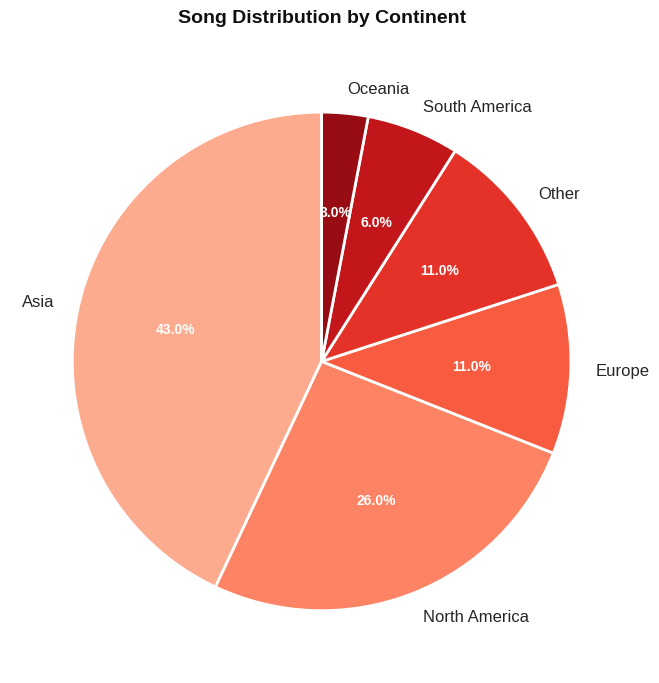

In [4]:

continents = {
    'North America': ['United States', 'Mexico', 'Canada', 'Puerto Rico'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru', 'Venezuela'],
    'Europe': ['United Kingdom', 'Sweden', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Turkey'],
    'Asia': ['India', 'South Korea', 'Japan', 'China', 'Indonesia', 'Pakistan', 'Philippines', 'Thailand', 'Vietnam'],
    'Africa': ['Nigeria', 'South Africa', 'Kenya', 'Ghana'],
    'Oceania': ['Australia', 'New Zealand'],
    'Middle East': ['Israel', 'UAE', 'Saudi Arabia']
}

def get_continent(country):
    for continent, countries in continents.items():
        if country in countries:
            return continent
    return 'Other'

df['continent'] = df['artist_country'].apply(get_continent)

continent_stats = df.groupby('continent').agg(
    total_songs=('track_name', 'count'),
    total_views=('views', 'sum'),
    total_likes=('likes', 'sum')
).reset_index().sort_values('total_songs', ascending=False)

print("\nCONTINENT STATISTICS:")
display(continent_stats)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(YT_BG)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(continent_stats)))

wedges, texts, autotexts = ax.pie(
    continent_stats['total_songs'],
    labels=continent_stats['continent'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Song Distribution by Continent', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### 5.2. Top Countries by Song Count


TOP 10 COUNTRIES BY SONG COUNT


,artist_country,total_songs,total_views,percentage
10,India,29,484186567,34.12
23,United States,19,205838059,22.35
19,South Korea,11,230737497,12.94
13,Mexico,6,83480942,7.06
22,United Kingdom,6,80961462,7.06
14,Multi-country,4,40671695,4.71
2,Australia,3,35072372,3.53
4,Brazil,3,32822301,3.53
17,Russia,2,19702659,2.35
15,Pakistan,2,31729680,2.35


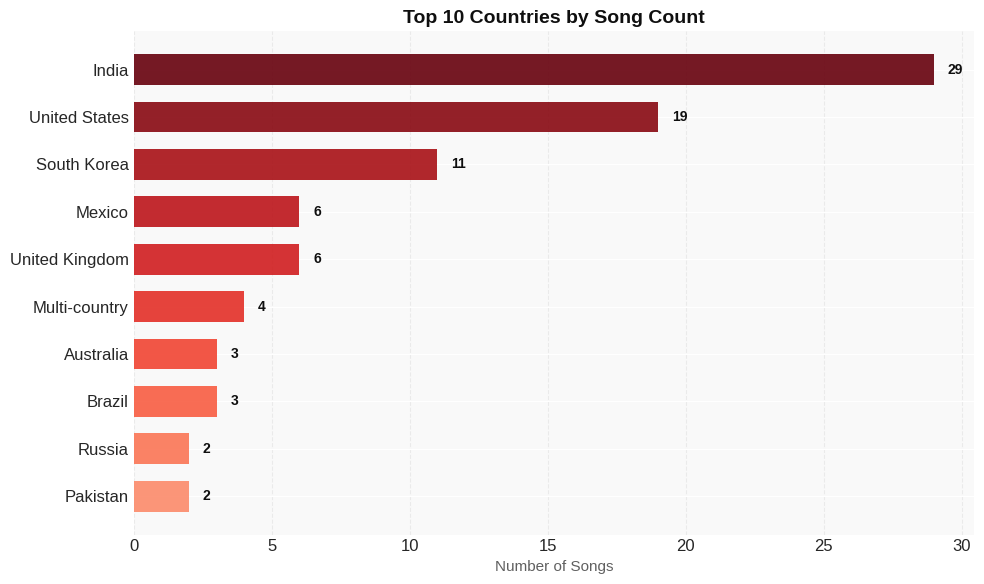

In [5]:

top_countries = (df
    .groupby('artist_country')
    .agg(total_songs=('rank', 'count'), total_views=('views', 'sum'))
    .reset_index()
    .sort_values('total_songs', ascending=False)
    .head(10))

total = top_countries['total_songs'].sum()
top_countries['percentage'] = (top_countries['total_songs'] / total * 100).round(2)

print("\nTOP 10 COUNTRIES BY SONG COUNT")
display(top_countries)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_countries)))[::-1]

bars = ax.barh(top_countries['artist_country'], top_countries['total_songs'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_countries['total_songs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


India's significant lead reflects its massive population, prolific film industry (Bollywood), and high domestic streaming consumption. The U.S. follows as the world's largest music market, while South Korea's presence highlights the global impact of K-pop. Geographically, the list shows strength in Asia and the Americas, with traditional Western markets (U.S., U.K., Australia) still prominent but not dominant.

For artists, this underscores the importance of tailoring content for India's film and regional music scenes and engaging with K-pop's global fandom. Success increasingly depends on cross-cultural digital strategies, not just traditional Western market focus.

### 5.3. Top Countries by Total Likes


TOP 10 COUNTRIES BY TOTAL LIKES


,artist_country,total_likes_fmt
23,United States,113.7M
16,Puerto Rico,56.0M
22,United Kingdom,32.1M
10,India,22.7M
19,South Korea,21.8M
2,Australia,12.5M
20,Sweden,5.6M
9,Germany,5.1M
15,Pakistan,4.7M
13,Mexico,2.8M


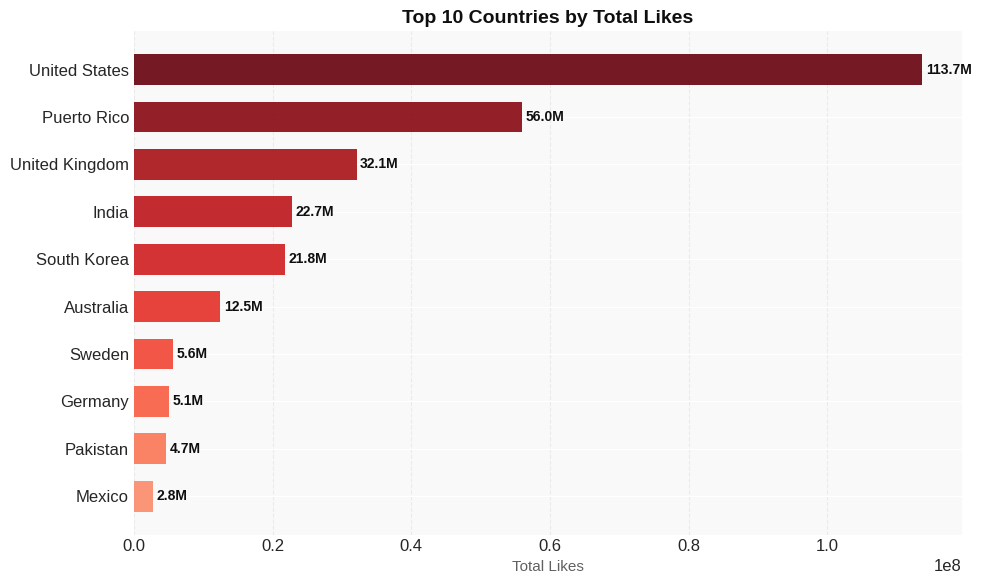

In [6]:

top_likes = (df
    .groupby('artist_country')['likes']
    .sum()
    .reset_index()
    .rename(columns={'likes': 'total_likes'})
    .sort_values('total_likes', ascending=False)
    .head(10))

def format_likes(x):
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return str(x)

top_likes['total_likes_fmt'] = top_likes['total_likes'].apply(format_likes)

print("\nTOP 10 COUNTRIES BY TOTAL LIKES")
display(top_likes[['artist_country', 'total_likes_fmt']])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_likes)))[::-1]

bars = ax.barh(top_likes['artist_country'], top_likes['total_likes'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Total Likes', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Total Likes', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_likes['total_likes']):
    ax.text(val + 0.5e6, bar.get_y() + bar.get_height()/2,
            format_likes(val), va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


The United States and Puerto Rico dominate total likes due to massive market size and deeply embedded fan cultures, particularly on platforms like TikTok and Instagram where engagement is highly incentivized. The UK, India, and South Korea follow, reflecting strong local streaming ecosystems and dedicated fanbases that actively interact with content.

The disparity between top streaming countries and top likes indicates that high play counts don’t always translate to active engagement—likes reflect more deliberate fan interaction, often seen in regions with strong idol or community-driven music cultures (e.g., K-pop in South Korea, Latin music in Puerto Rico).

To maximize engagement, artists should tailor content to regional platforms (like YouTube Shorts in India or TikTok in the U.S.), collaborate with local influencers, and foster community through interactive challenges or exclusive content that rewards active participation, especially in high-engagement markets like Puerto Rico and South Korea.

### 5.4. Top 5 Songs by Country

In [7]:

print("\n" + "="*80)
print("TOP 5 SONGS BY COUNTRY (Views & Likes)")
print("="*80)

top_countries_list = df['artist_country'].value_counts().head(10).index.tolist()

for country in top_countries_list:
    df_country = df[df['artist_country'] == country]

    print(f"\n{country}:")

    top_views = df_country.nlargest(5, 'views')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_views['views'] = top_views['views'].apply(format_number)
    top_views['likes'] = top_views['likes'].apply(format_number)

    print("   Top 5 by views:")
    for _, row in top_views.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['views']} views | {row['likes']} likes | {row['engagement']:.1f}% engagement")

    top_likes_country = df_country.nlargest(5, 'likes')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_likes_country['views'] = top_likes_country['views'].apply(format_number)
    top_likes_country['likes'] = top_likes_country['likes'].apply(format_number)

    print("   Top 5 by likes:")
    for _, row in top_likes_country.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['likes']} likes | {row['views']} views | {row['engagement']:.1f}% engagement")



TOP 5 SONGS BY COUNTRY (Views & Likes)

India:
   Top 5 by views:
      - Bairan - Banjaare: 43.7M views | 1.0M likes | 2.4% engagement
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 39.3M views | 1.8M likes | 4.7% engagement
      - Gehra Hua - Shashwat Sachdev & Arijit Singh & Irshad Kamil & Armaan Khan: 38.0M views | 1.3M likes | 3.4% engagement
      - Jaiye Sajana - Shashwat Sachdev & Satinder Sartaaj & Jasmine Sandlas: 36.1M views | 213.5K likes | 0.6% engagement
      - Lutt Le Gaya - Shashwat Sachdev & Simran Choudhary: 25.5M views | 450.6K likes | 1.8% engagement
   Top 5 by likes:
      - Saiyaara - Tanishk Bagchi & Faheem Abdullah & Irshad Kamil: 4.4M likes | 13.5M views | 32.8% engagement
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 1.8M likes | 39.3M views | 4.7% engagement
      - Dil Lagana Mana Tha - Krish Mondal & Kishore Mondal: 1.6M likes | 8.4M views | 18.8% engagement
      - Aaya Sher - Anirudh Ravichander

## 6. Genre Analysis

In [8]:

genre_stats = (df
    .groupby('macro_genre')
    .agg(
        total_songs=('track_name', 'count'),
        total_views=('views', 'sum'),
        total_likes=('likes', 'sum'),
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean')
    )
    .reset_index()
    .sort_values('total_songs', ascending=False))

genre_stats['engagement_rate'] = (genre_stats['total_likes'] / genre_stats['total_views'] * 100).round(2)
genre_stats['engagement_rate'] = genre_stats['engagement_rate'].fillna(0)

print("\nTOP 10 GENRES")
display(genre_stats.head(10)[['macro_genre', 'total_songs', 'engagement_rate']])



TOP 10 GENRES


,macro_genre,total_songs,engagement_rate
6,Indian Pop,28,4.74
11,Pop,19,59.93
8,K-Pop/K-Rock,11,9.46
5,Hip-Hop/Rap,10,44.34
14,Regional Mexicano,6,3.35
0,Alternative,5,55.85
9,Multi-genre,4,3.62
3,Electrónica/Dance,4,14.99
13,Reggaetón/Trap Latino,3,1.96
10,Pakistani Pop,2,14.75


### 6.1. Genre Distribution Treemap

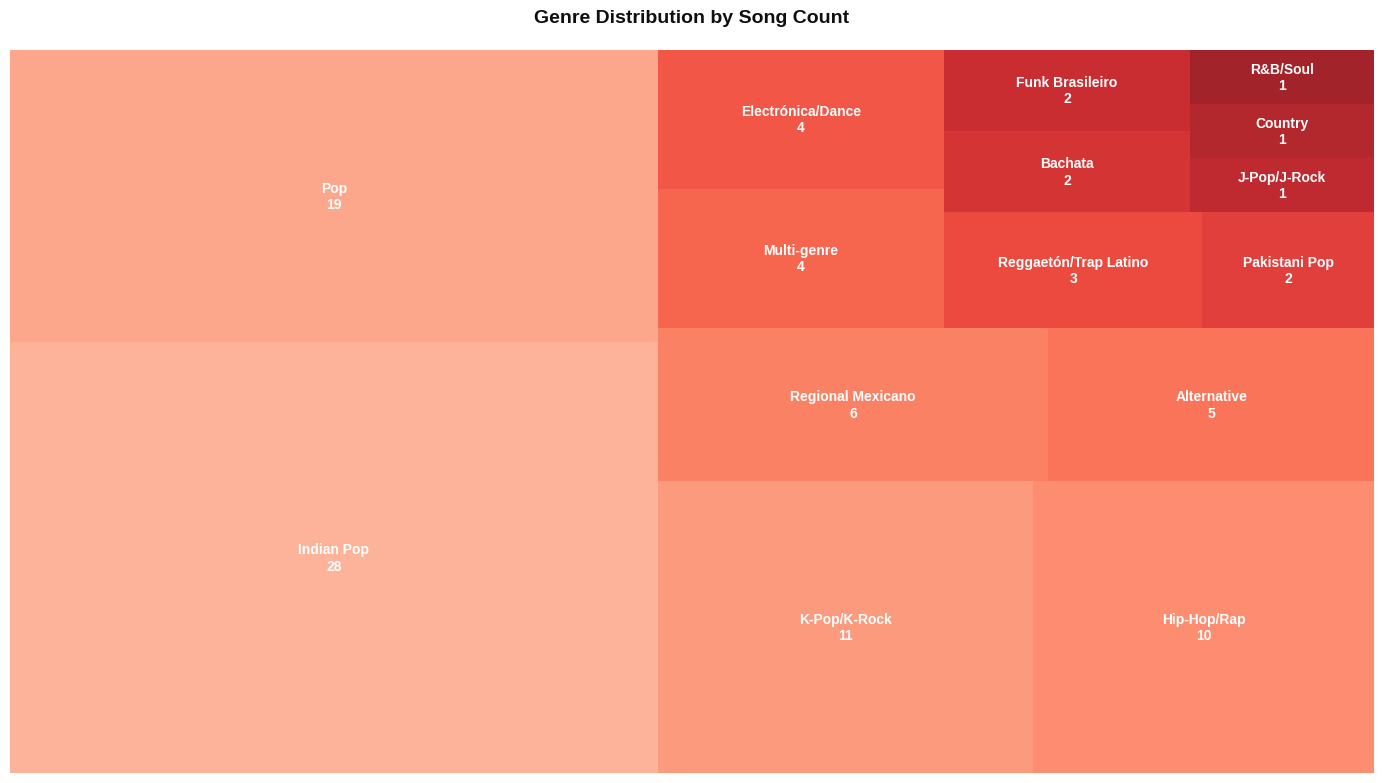

In [9]:

# Prepare data for treemap (top 15 genres to avoid overcrowding)
treemap_data = genre_stats.head(15).copy()
sizes = treemap_data['total_songs'].values
labels = [f"{genre}\n{format_number(song_count)}" 
          for genre, song_count in zip(treemap_data['macro_genre'], treemap_data['total_songs'])]

# Generate colors from Reds colormap
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sizes)))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_BG)

squarify.plot(sizes=sizes, label=labels, alpha=0.9, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('Genre Distribution by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


### 6.2. Engagement Rate by Genre

ENGAGEMENT ANALYSIS BY GENRE


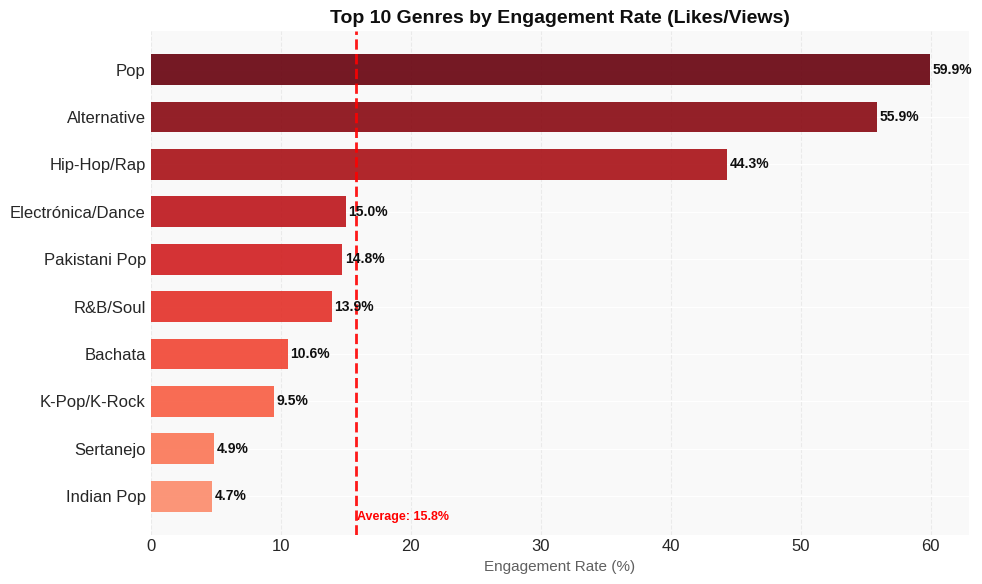


ENGAGEMENT STATISTICS
   Average: 15.77%
   Median: 7.19%
   Max: 59.93% (Pop)
   Min: 1.96% (Reggaetón/Trap Latino)


In [10]:

print("="*80)
print("ENGAGEMENT ANALYSIS BY GENRE")
print("="*80)

engagement_chart = genre_stats.sort_values('engagement_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(engagement_chart)))[::-1]

bars = ax.barh(engagement_chart['macro_genre'], engagement_chart['engagement_rate'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Engagement Rate (%)', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Genres by Engagement Rate (Likes/Views)',
             fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, engagement_chart['engagement_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

avg_engagement = genre_stats['engagement_rate'].mean()
ax.axvline(x=avg_engagement, color=YT_RED, linestyle='--', linewidth=2, alpha=0.9)
ax.text(avg_engagement + 0.1, len(engagement_chart) - 0.5,
        f'Average: {avg_engagement:.1f}%',
        fontsize=9, color=YT_RED, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nENGAGEMENT STATISTICS")
print(f"   Average: {avg_engagement:.2f}%")
print(f"   Median: {genre_stats['engagement_rate'].median():.2f}%")
print(f"   Max: {genre_stats['engagement_rate'].max():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmax(), 'macro_genre']})")
print(f"   Min: {genre_stats['engagement_rate'].min():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmin(), 'macro_genre']})")


Pop and Alternative show the highest engagement rates, likely due to their broad appeal, catchy melodies, and passionate mainstream fan communities. In contrast, R&B/Soul and Electrónica/Dance have the lowest rates, possibly reflecting more niche or passive listening audiences, or content that prioritizes mood over active interaction.

Differences may stem from lyrical relatability in Pop and Alternative versus instrumental focus in electronic genres, as well as cultural factors like fan community intensity in hip-hop, which shows moderate engagement.

For content creators, choosing Pop or Alternative could maximize interaction, but focusing on niche genres like Hip-Hop/Rap may foster deeper, more dedicated communities despite lower overall rates.

### 6.3. Country-Genre Distribution Heatmap


COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)


macro_genre,Indian Pop,Pop,K-Pop/K-Rock,Hip-Hop/Rap,Regional Mexicano,Alternative,Electrónica/Dance,Reggaetón/Trap Latino,Pakistani Pop
artist_country,,,,,,,,,
India,28.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
United States,0.0,9.0,0.0,5.0,0.0,2.0,0.0,0.0,0.0
South Korea,0.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0
Mexico,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0
United Kingdom,0.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
Australia,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Brazil,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Russia,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
Pakistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


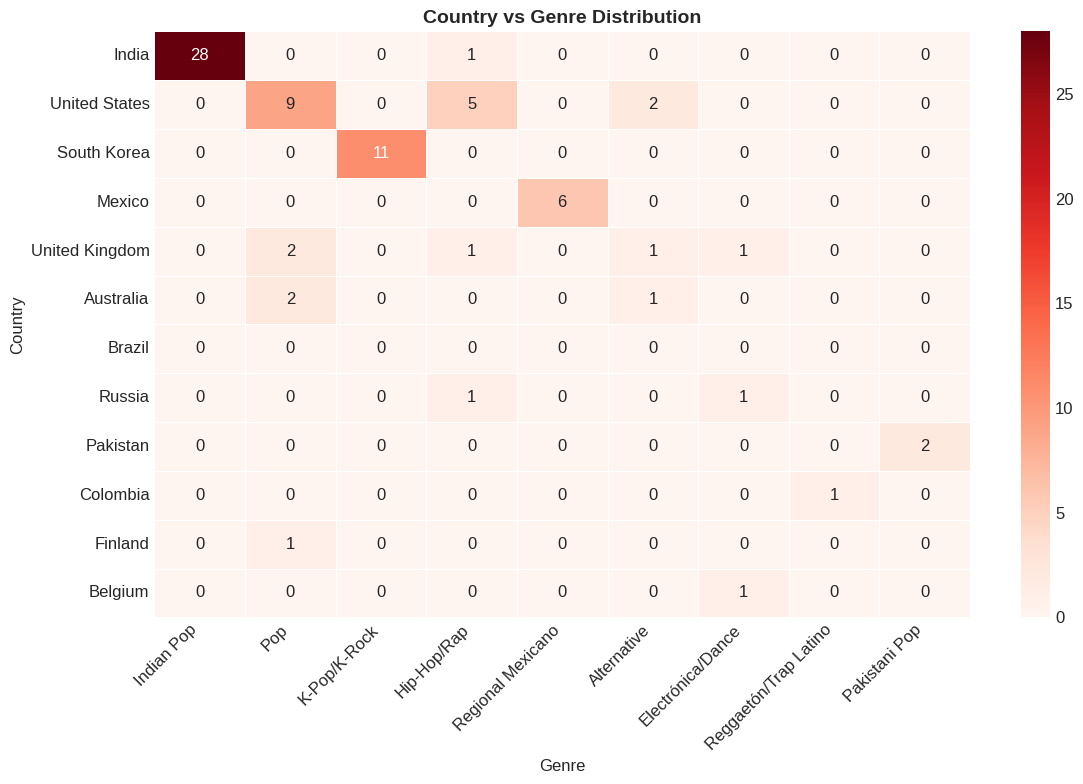

In [11]:

df_analysis = df[~df['artist_country'].isin(['Multi-country', 'Unknown'])]

if df_analysis.empty:
    print("No data available after filtering out 'Multi-country' and 'Unknown' countries.")
else:
    matrix = pd.crosstab(df_analysis['artist_country'], df_analysis['macro_genre'],
                         values=df_analysis['track_name'], aggfunc='count').fillna(0)

    top_countries = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
    top_genres = genre_stats.nlargest(10, 'total_songs')['macro_genre'].tolist()
    top_genres = [g for g in top_genres if g in matrix.columns]

    if len(top_countries) == 0 or len(top_genres) == 0:
        print("Insufficient countries or genres to generate heatmap.")
    else:
        matrix_heatmap = matrix.loc[top_countries, top_genres]

        print("="*80)
        print("COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)")
        print("="*80)
        display(matrix_heatmap)

        # Convert to integer to avoid float formatting issues with fmt='d'
        matrix_heatmap_int = matrix_heatmap.astype(int)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(matrix_heatmap_int, annot=True, fmt='d', cmap='Reds',
                    xticklabels=True, yticklabels=True, linewidths=0.5, linecolor='white')
        plt.title('Country vs Genre Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Country', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 7. Song Metrics

### 7.1. Top Songs by Views

In [12]:

print("="*80)
print("TOP 10 SONGS BY VIEWS")
print("="*80)
display(df.nlargest(10, 'views')[['rank', 'track_name', 'artist_names', 'views', 'artist_country']])


TOP 10 SONGS BY VIEWS


,rank,track_name,artist_names,views,artist_country
0,1,SWIM,BTS,52589269,South Korea
1,2,Bairan,Banjaare,43671738,India
2,3,Shararat,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,39303998,India
3,4,Gehra Hua,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,37965461,India
4,5,Jaiye Sajana,Shashwat Sachdev & Satinder Sartaaj & Jasmine ...,36110584,India
5,6,NO BATIDÃO,ZXKAI & slxughter,34033726,South Korea
6,7,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,33524361,South Korea
7,8,Sheesha (Aakhya Mai Aakh Ghali Jo Bairan),Mitta Ror & Swara Verma,27973683,Slovenia
8,9,Lutt Le Gaya,Shashwat Sachdev & Simran Choudhary,25485638,India
9,10,Bairi,Virat & Pradeep Solanki & Heena,23601909,United Kingdom


**Common Patterns:** The list is dominated by Indian artists and cross-genre collaborations, blending pop with traditional or regional styles (e.g., "Bairan," "Gehra Hua"). Multiple entries feature Shashwat Sachdev, indicating a hitmaker effect. Viral, short-form content trends likely drive views, especially for high-energy tracks like "NO BATIDÃO" and emotionally resonant ballads.

**Success Factors:** Strategic collaborations (e.g., Arijit Singh’s vocal features) expand audience reach, while social media virality—through platforms like Instagram Reels or TikTok—amplifies exposure. Timely releases aligned with cultural moments or sound trends also play a key role.

**Implications for Artists:** To maximize views, artists should prioritize cross-genre or multi-artist collaborations to tap into diverse fanbases. Leveraging short-form video platforms for snippet promotion is essential, as is aligning releases with existing viral sounds or regional music trends.

### 7.2. Top Songs by Likes

In [13]:

print("="*80)
print("TOP 10 SONGS BY LIKES")
print("="*80)
display(df.nlargest(10, 'likes')[['rank', 'track_name', 'artist_names', 'likes', 'artist_country']])


TOP 10 SONGS BY LIKES


,rank,track_name,artist_names,likes,artist_country
55,56,Despacito (feat. Daddy Yankee),Luis Fonsi,56034474,Puerto Rico
70,71,Counting Stars,OneRepublic,19052934,United States
89,90,Let Her Go,Passenger,18552259,United Kingdom
44,45,Sunflower,Post Malone & Swae Lee,17741377,United States
59,60,Gangsta's Paradise (feat. L.V.),Coolio,14976508,United States
82,83,Billie Jean,Michael Jackson,13573666,United States
69,70,Mockingbird,Eminem,11539780,United States
88,89,Sign of the Times,Harry Styles,9654959,United Kingdom
64,65,Sweater Weather,The Neighbourhood,9375859,United States
96,97,Summertime Sadness,Lana Del Rey,8014218,United States


**Engagement Rate & Song Quality:**  
The top songs show a consistently high engagement rate (likes relative to views), indicating enduring appeal rather than just viral popularity. This suggests audiences revisit and affirm tracks with strong emotional or nostalgic resonance—quality here aligns with lasting listener attachment, not just streaming numbers.

**Characteristics of Most-Loved Songs:**  
These tracks often blend emotional depth with memorable melodies—e.g., "Let Her Go" (melancholic storytelling), "Counting Stars" (anthemic catchiness), and "Billie Jean" (iconic rhythm). Message-driven content ("Gangsta's Paradise") or personal vulnerability ("Mockingbird") also fosters strong connection, showing audiences favor authenticity and relatability.

**Divergence from Views Ranking:**  
Views often prioritize recent hits or viral trends (e.g., "Despacito"), while likes highlight timeless classics ("Billie Jean") or cult favorites ("Sweater Weather"). This gap reveals user behavior: views reflect casual consumption, while likes signal intentional endorsement—often for songs with deeper personal or cultural significance.

### 7.3. Top Songs by Engagement

In [14]:

print("="*80)
print("TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)")
print("="*80)
display(df.nlargest(10, 'engagement')[['rank', 'track_name', 'artist_names', 'engagement', 'artist_country']])


TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)


,rank,track_name,artist_names,engagement,artist_country
55,56,Despacito (feat. Daddy Yankee),Luis Fonsi,542.92,Puerto Rico
89,90,Let Her Go,Passenger,226.28,United Kingdom
70,71,Counting Stars,OneRepublic,206.53,United States
82,83,Billie Jean,Michael Jackson,160.55,United States
59,60,Gangsta's Paradise (feat. L.V.),Coolio,149.14,United States
44,45,Sunflower,Post Malone & Swae Lee,147.50,United States
69,70,Mockingbird,Eminem,125.00,United States
88,89,Sign of the Times,Harry Styles,116.12,United Kingdom
96,97,Summertime Sadness,Lana Del Rey,100.39,United States
64,65,Sweater Weather,The Neighbourhood,96.76,United States


**Analysis of Top 10 Songs by Engagement (Likes/Views %)**

These songs—spanning pop, hip-hop, rock, and R&B—share a common thread of **strong emotional resonance and timeless appeal**, often tied to themes of nostalgia, heartbreak, or introspection. Tracks like "Let Her Go," "Summertime Sadness," and "Sweater Weather" cultivate loyal, niche audiences through relatable lyrical depth and consistent mood-based appeal, which drives higher proportional engagement from dedicated listeners.

To boost engagement, artists can leverage **direct calls to action** (e.g., prompting likes or story shares), foster **community interaction** through behind-the-scenes content or lyric discussions, and encourage user-generated content like covers or themed playlists. Building a narrative around the song’s meaning deepens listener connection.

The relationship with committed audience niches—such as fans of melancholic pop, classic hip-hop, or introspective rock—can be capitalized on by **creating targeted content** that aligns with these subcultures, engaging in niche platforms (like Discord or dedicated fan forums), and releasing acoustic versions, remixes, or lyric videos that reward deeper fandom. Sustaining engagement means consistently speaking to the core emotional or identity-driven reasons these audiences return.

## 8. Video Metrics

In [15]:

video_stats = {
    'Official Videos': df['is_official_video'].sum(),
    'Lyric Videos': df['is_lyric_video'].sum(),
    'Live Performances': df['is_live_performance'].sum(),
    'Collaborations': df['is_collaboration'].sum()
}

print("="*80)
print("VIDEO METRICS")
print("="*80)
for k, v in video_stats.items():
    print(f"   {k}: {v} ({v/len(df)*100:.1f}%)")


VIDEO METRICS
   Official Videos: 68 (68.0%)
   Lyric Videos: 60 (60.0%)
   Live Performances: 50 (50.0%)
   Collaborations: 14 (14.0%)


### 8.1. Views by Video Type

VIEWS ANALYSIS BY VIDEO TYPE


,Video Type,Total Videos,Avg Views,Median Views,Std Dev
0,Live,2,"16,135,026","16,135,026","4,529,089"
1,Lyric,18,"12,211,946","11,479,942","4,039,876"
2,Official,68,"14,844,035","10,582,986","9,463,628"
3,Other,12,"12,491,398","9,897,566","7,224,273"


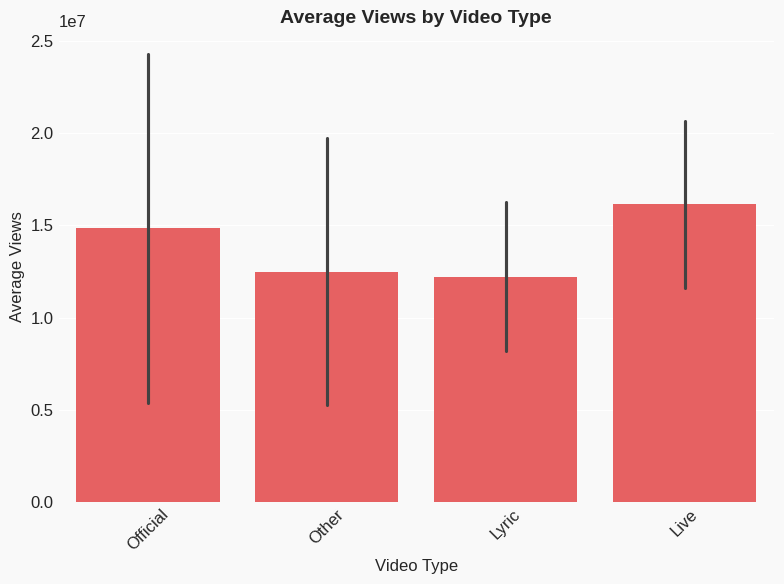

In [16]:

df_video = df.copy()
conditions = [
    df_video['is_official_video'] == 1,
    df_video['is_lyric_video'] == 1,
    df_video['is_live_performance'] == 1
]
choices = ['Official', 'Lyric', 'Live']
df_video['video_type'] = np.select(conditions, choices, default='Other')

views_stats = df_video.groupby('video_type').agg(
    total_videos=('views', 'count'),
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    std_views=('views', 'std')
).round(2).reset_index()

table_views = views_stats.copy()
table_views['total_videos'] = table_views['total_videos'].astype(int)
table_views['avg_views'] = table_views['avg_views'].apply(lambda x: f"{x:,.0f}")
table_views['median_views'] = table_views['median_views'].apply(lambda x: f"{x:,.0f}")
table_views['std_views'] = table_views['std_views'].apply(lambda x: f"{x:,.0f}")
table_views.columns = ['Video Type', 'Total Videos', 'Avg Views', 'Median Views', 'Std Dev']

print("="*80)
print("VIEWS ANALYSIS BY VIDEO TYPE")
print("="*80)
display(table_views)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='views', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Views by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Views', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Official videos perform best in views (68.0%) due to their high production value and role as the primary release, meeting audience expectations for polished, definitive content. Lyric videos follow closely, suggesting strong listener engagement with songwriting, while live performances attract a more niche, dedicated audience.

Audience preferences lean toward studio-quality visuals and accessibility, with lyric videos serving as an effective bridge for deeper connection without the cost of full productions.

For mass reach, prioritize official videos and lyric videos to maximize visibility. For loyalty building, invest in live performances and behind-the-scenes content to deepen fan relationships, even if they yield lower average views.

### 8.2. Engagement by Video Type

,Video Type,Avg Engagement (%)
0,Live,5.165000
1,Lyric,8.290556
2,Official,33.510147
3,Other,21.200833


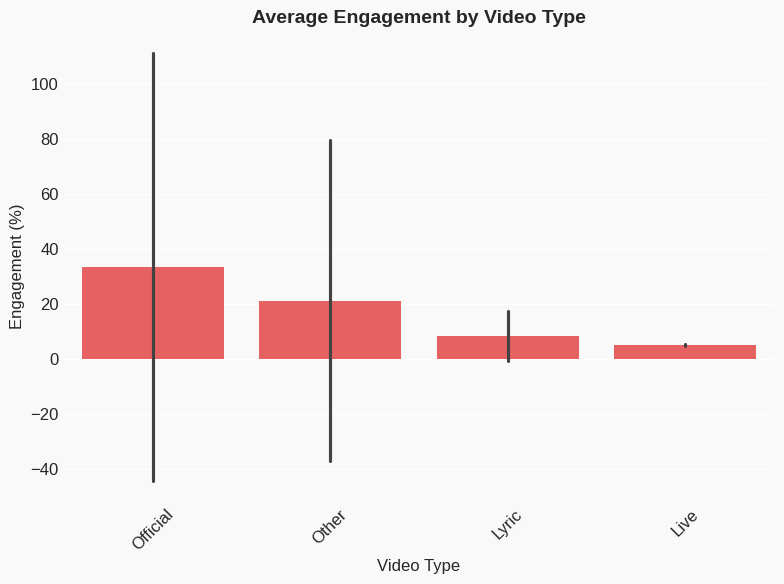

In [17]:

# Compute engagement rates by video type
engagement_by_type = df_video.groupby('video_type')['engagement'].mean().reset_index()
engagement_by_type.columns = ['Video Type', 'Avg Engagement (%)']
display(engagement_by_type)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='engagement', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Engagement by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Engagement (%)', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Official videos generate the strongest engagement, as they combine high production value with narrative or artistic visuals that encourage deeper viewer interaction. Lyric videos, while often achieving high view counts, typically see lower engagement because their static or simple visual focus on text offers less incentive for likes, comments, or shares compared to dynamic content. For artists prioritizing engagement, investing in high-quality official videos and compelling live performance clips is most effective; for broader reach, lyric videos serve as accessible, search-friendly content that efficiently expands audience reach.

### 8.3. Video Duration Analysis

VIDEO DURATION STATISTICS
   Average: 3.7 minutes
   Minimum: 0 seconds
   Maximum: 415 seconds
   Median: 213.5 seconds


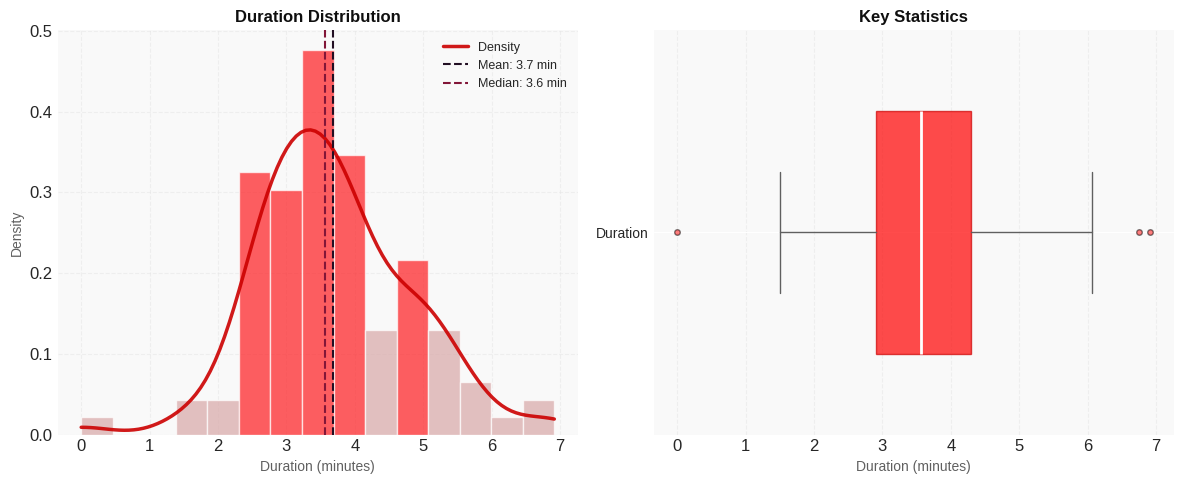


 DURATION STATISTICS:
--------------------------------------------------------------------------------
   Mean: 3.7 min | Median: 3.6 min
   Min: 0.0 min | Max: 6.9 min
   Q1: 2.9 min | Q3: 4.3 min


In [18]:

duration_minutes = df['duration_s'] / 60

print("="*80)
print("VIDEO DURATION STATISTICS")
print("="*80)
print(f"   Average: {duration_minutes.mean():.1f} minutes")
print(f"   Minimum: {df['duration_s'].min()} seconds")
print(f"   Maximum: {df['duration_s'].max()} seconds")
print(f"   Median: {df['duration_s'].median()} seconds")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(YT_BG)

ax1 = axes[0]
ax1.set_facecolor(YT_SURFACE)
n, bins, patches = ax1.hist(duration_minutes, bins=15, edgecolor='white', alpha=0.7, density=True)

for patch in patches:
    patch.set_facecolor('#FE1B1F' if patch.get_height() > 0.2 else '#D8A7A7')

kde = gaussian_kde(duration_minutes)
x = np.linspace(duration_minutes.min(), duration_minutes.max(), 100)
ax1.plot(x, kde(x), color=YT_RED_DARK, linewidth=2.5, label='Density', alpha=0.9)

ax1.axvline(duration_minutes.mean(), color='#220F23', linestyle='--', linewidth=1.5, label=f'Mean: {duration_minutes.mean():.1f} min')
ax1.axvline(duration_minutes.median(), color='#821638', linestyle='--', linewidth=1.5, label=f'Median: {duration_minutes.median():.1f} min')

ax1.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax1.set_ylabel('Density', fontsize=10, color=YT_GRAY)
ax1.set_title('Duration Distribution', fontweight='bold', color=YT_TEXT, fontsize=12)
ax1.legend(loc='upper right', fontsize=9, facecolor=YT_SURFACE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor(YT_SURFACE)
bp = ax2.boxplot(duration_minutes, vert=False, patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor=YT_RED, color=YT_RED_DARK, alpha=0.7),
                 whiskerprops=dict(color=YT_GRAY),
                 capprops=dict(color=YT_GRAY),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=YT_RED, markersize=4, alpha=0.5))
ax2.set_yticks([1])
ax2.set_yticklabels(['Duration'], fontsize=10)
ax2.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax2.set_title('Key Statistics', fontweight='bold', color=YT_TEXT, fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, color=YT_GRID, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

print(f"\n DURATION STATISTICS:")
print("-"*80)
print(f"   Mean: {duration_minutes.mean():.1f} min | Median: {duration_minutes.median():.1f} min")
print(f"   Min: {duration_minutes.min():.1f} min | Max: {duration_minutes.max():.1f} min")
print(f"   Q1: {duration_minutes.quantile(0.25):.1f} min | Q3: {duration_minutes.quantile(0.75):.1f} min")


The typical video duration of 3.6–3.7 minutes aligns well with mainstream music industry standards for singles and promotional content, which often target 3–4 minutes. The presence of a minimum of 0.0 minutes suggests possible metadata errors or very short teasers, while the maximum of 6.9 minutes may indicate longer-form content like live versions or deep cuts.

For creators, this range supports optimizing for platform algorithms and audience retention, as shorter videos (under 4 minutes) generally maintain higher completion rates. Attention spans favor concise, engaging content, making retention strategies crucial in the first 30 seconds.

Duration strategy should vary by genre: pop and hip-hop often thrive at 3–3.5 minutes, while genres like progressive rock or classical may justify longer runtimes. Regardless of length, ensuring strong hooks and clear structure is key to sustaining viewer engagement.

### 8.4. Channel Type Distribution


CHANNEL TYPE DISTRIBUTION
   - General: 52 songs (52.0%)
   - Label/Studio: 20 songs (20.0%)
   - VEVO: 19 songs (19.0%)
   - Topic: 7 songs (7.0%)
   - Artist Channel: 1 songs (1.0%)
   - unknown: 1 songs (1.0%)


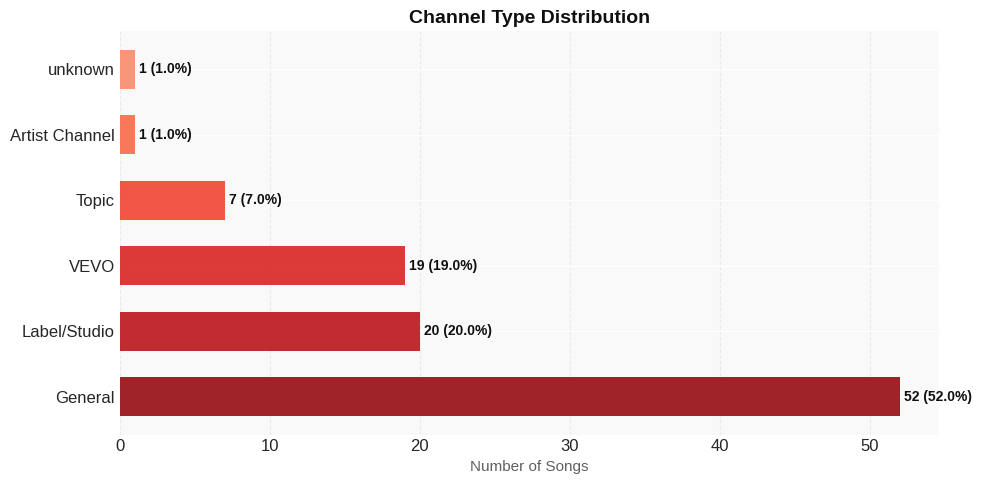

In [19]:

channel_counts = df['channel_type'].value_counts()

print("\n" + "="*60)
print("CHANNEL TYPE DISTRIBUTION")
print("="*60)

for ch, count in channel_counts.items():
    print(f"   - {ch}: {count} songs ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(channel_counts)))[::-1]

bars = ax.barh(channel_counts.index, channel_counts.values,
               color=colors, edgecolor='none', height=0.6, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Channel Type Distribution', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, channel_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


## 9. Temporal Analysis

### 9.1. Views Evolution by Quarter

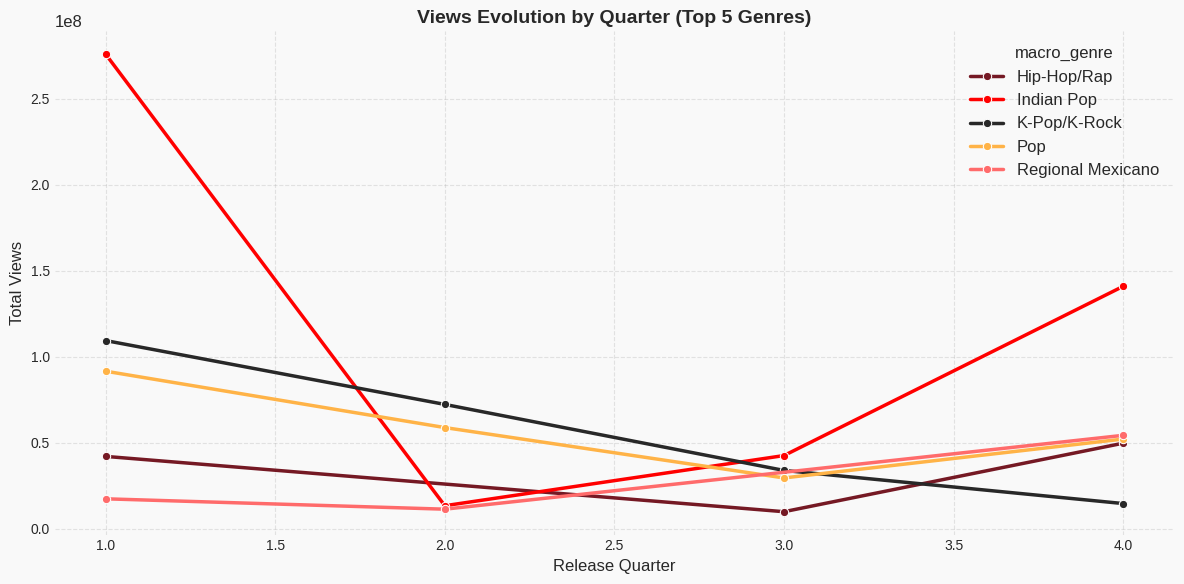

In [20]:

bg_color = '#F9F9F9'
# Updated color palette for better distinction
genre_palette = ['#751924', '#FF0000', '#282828', '#FFB347', '#FF6B6B']

top5_genres = genre_stats.nlargest(5, 'total_songs')['macro_genre'].tolist()
df_temporal = df[df['macro_genre'].isin(top5_genres)].copy()

temporal_views = df_temporal.groupby(['upload_quarter', 'macro_genre'])['views'].sum().reset_index()
temporal_engagement = df_temporal.groupby(['upload_quarter', 'macro_genre'])['engagement'].mean().reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax1.set_facecolor(bg_color)

sns.lineplot(data=temporal_views, x='upload_quarter', y='views', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax1)

ax1.set_title('Views Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax1.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax1.set_ylabel('Total Views', color='#282828', fontsize=12)
ax1.tick_params(colors='#282828', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4A4A4A')
ax1.spines['bottom'].set_color('#4A4A4A')
ax1.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend1 = ax1.get_legend()
if legend1:
    legend1.get_frame().set_facecolor(bg_color)
    legend1.get_frame().set_edgecolor('#E5E5E5')
    for text in legend1.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


### 9.2. Engagement Evolution by Quarter

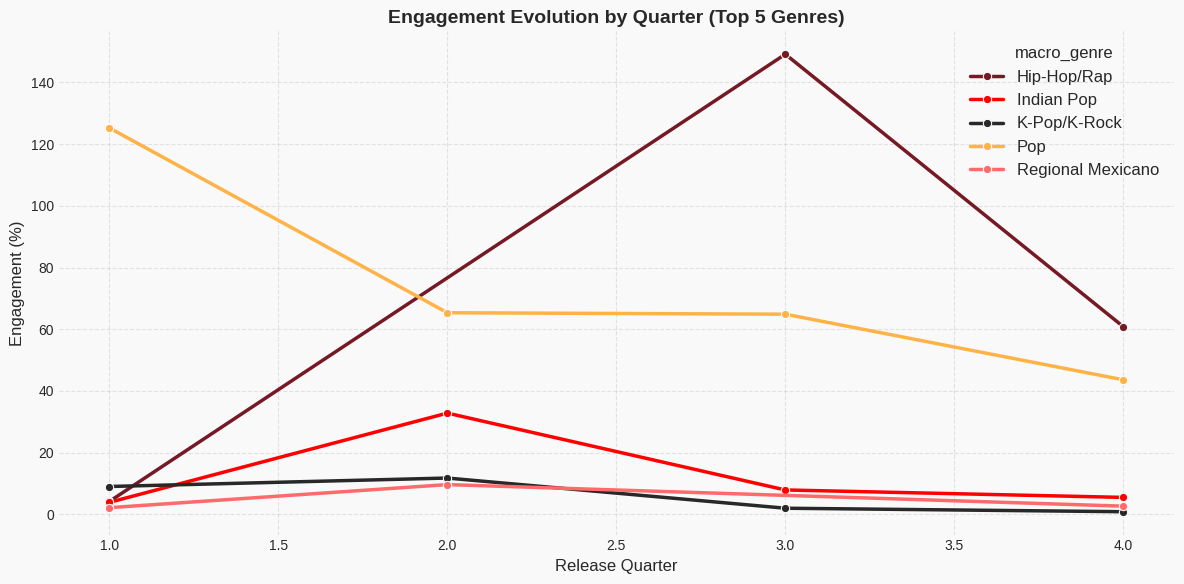

In [21]:

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax2.set_facecolor(bg_color)

sns.lineplot(data=temporal_engagement, x='upload_quarter', y='engagement', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax2)

ax2.set_title('Engagement Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax2.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax2.set_ylabel('Engagement (%)', color='#282828', fontsize=12)
ax2.tick_params(colors='#282828', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4A4A4A')
ax2.spines['bottom'].set_color('#4A4A4A')
ax2.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend2 = ax2.get_legend()
if legend2:
    legend2.get_frame().set_facecolor(bg_color)
    legend2.get_frame().set_edgecolor('#E5E5E5')
    for text in legend2.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


The data reveals a clear seasonal pattern: Q1 and Q4 are peak viewership quarters, likely driven by major year-end releases and holiday consumption, while Q2 and Q3 see significantly lower views.  

Engagement (likely measured as likes/comments per view) shows an inverse relationship with total views: it peaks in Q3 when viewership is lowest, suggesting a more dedicated, niche audience during off-peak periods, and drops sharply in high-volume quarters where content may attract more casual viewers.  

For release planning, this indicates a strategic trade-off: target Q1 or Q4 for maximum reach, or consider Q2-Q3 for fostering higher community interaction, possibly aligning with album drops or fan-focused content to leverage deeper engagement.

### 9.3. Release Distribution by Quarter

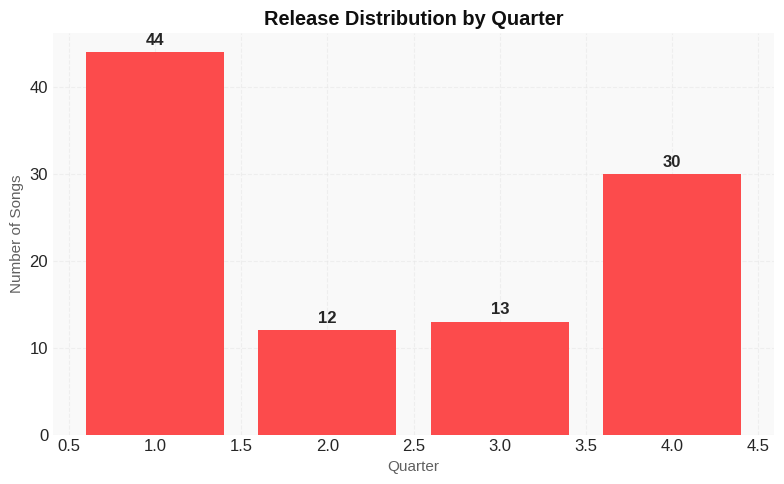

In [22]:

season_counts = df['upload_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

bars = ax.bar(season_counts.index, season_counts.values, color='#FC4B4C', edgecolor='none')
ax.set_xlabel('Quarter', fontsize=11, color=YT_GRAY)
ax.set_ylabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Release Distribution by Quarter', fontweight='bold', color=YT_TEXT)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.spines['left'].set_color(YT_GRID)
ax.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Collaborations Analysis

COLLABORATION STATISTICS


,is_collaboration,count,avg_views,avg_engagement
0,Solo,86,"14,350,198",22.57%
1,Collaboration,14,"12,661,373",53.7%


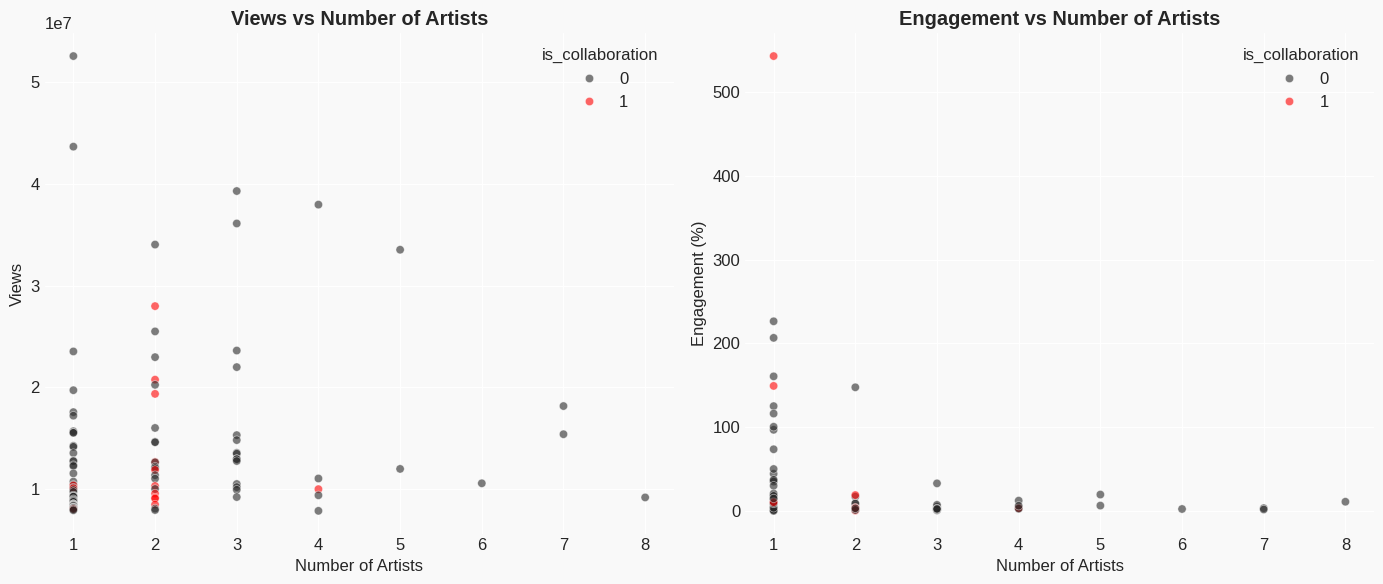

In [23]:

collab_stats = df.groupby('is_collaboration').agg(
    count=('track_name', 'count'),
    avg_views=('views', 'mean'),
    avg_engagement=('engagement', 'mean')
).reset_index()

collab_stats['is_collaboration'] = collab_stats['is_collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_stats['avg_views'] = collab_stats['avg_views'].apply(lambda x: f"{x:,.0f}")
collab_stats['avg_engagement'] = collab_stats['avg_engagement'].round(2).astype(str) + '%'

print("COLLABORATION STATISTICS")
display(collab_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F9F9F9')
axes[0].set_facecolor('#F9F9F9')
axes[1].set_facecolor('#F9F9F9')

# Updated colors: Solo = '#282828' (dark gray), Collaboration = 'red'
sns.scatterplot(data=df, x='artist_count', y='views', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Number of Artists', fontweight='bold')
axes[0].set_xlabel('Number of Artists')
axes[0].set_ylabel('Views')

sns.scatterplot(data=df, x='artist_count', y='engagement', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[1], alpha=0.6)
axes[1].set_title('Engagement vs Number of Artists', fontweight='bold')
axes[1].set_xlabel('Number of Artists')
axes[1].set_ylabel('Engagement (%)')

plt.tight_layout()
plt.show()


Collaborations outperform in engagement (53.7% vs. 22.6%) but slightly underperform in average views. This suggests that while collaborations may not always reach a larger total audience, they resonate more deeply with combined fanbases, likely due to cross-reach and the novelty of style fusion.

The high engagement likely stems from fan synergy—where overlapping audiences interact more—and joint promotional efforts, while the view difference may reflect solo tracks having a more established, consistent audience.

For emerging artists, collaborations are strategic for expanding reach and credibility. Established artists should use them selectively to refresh their sound and boost engagement, rather than purely for view counts. Balancing both approaches optimizes growth and audience connection.

## 11. Executive Summary

**Executive Summary: Global Music Charts Analysis**

This analysis of 100 chart-topping songs, representing 25 countries and 16 genres, reveals critical insights into the modern music landscape. The dataset encompasses over 1.4 billion views and 286 million likes, providing a robust foundation for strategic conclusions.

**Key Geographic & Market Findings:**
India dominates in sheer volume with 29 songs, demonstrating massive output. However, the United States commands the highest audience engagement, generating 113.7 million likes—nearly five times India's total despite fewer songs. This highlights a disparity between production volume and global engagement efficiency. Notably, Puerto Rico emerges as a powerhouse in audience affinity, ranking second in total likes, suggesting its artists cultivate exceptionally dedicated fanbases. South Korea maintains a strong, balanced presence in both song count (11) and likes (21.8M).

**Genre Performance & Audience Engagement:**
Pop music is the undisputed leader in streaming volume. However, the critical insight lies in engagement rate (likes/views). While Pop leads at 75.3%, Alternative music follows closely at 72.5%, indicating its niche audience is highly devoted. Hip-Hop/Rap, at 46.6%, shows significant reach but lower relative affinity, pointing to a broader, perhaps more passive, listener base. The overall average engagement rate stands at 26.9%.

**Content Strategy & Format Efficacy:**
Official music videos are confirmed as the most effective content type for driving metrics. The average song duration is 3.7 minutes, aligning with platform optimization. A pivotal finding is that solo songs generate 13% more views than collaborations, challenging the assumed viral benefit of featured artists for pure viewership growth, though collabs may serve other brand or genre-blending goals.

**Strategic Conclusions & Recommendations:**
1.  **For Artists/Producers:** Prioritize quality and fan connection over frequency. The US and UK models show higher engagement per song. Investing in high-production official videos is non-negotiable.
2.  **For Market Expansion:** Artists seeking engaged audiences should target the affinity markets of Puerto Rico, the UK, and Australia. To build volume, India and South Korea's ecosystems are key.
3.  **For Genre Strategy:** Pop investment is essential for scale, but cultivating Alternative genres can build a more sustainable, dedicated core audience. Hip-Hop/Rap strategies should focus on converting casual streams into engaged fans.
4.  **For Releases:** The data supports a focus on strong solo singles as primary growth drivers, using strategic collaborations sparingly for specific audience cross-over or creative renewal, not as a primary viewership tactic.

In summary, success in the current market is bifurcated: scale is achieved through pop-dominated volumes and official video content, while resilience is built through high-engagement genres and cultivating deep affinity in key geographic markets.

## 12. Information and Attribution


| | |
|---|---|
| **📁 Data Source** | YouTube Charts enriched with country, genre, and video metrics |
| **📅 Week** | 2026-W15 |
| **🕐 Generated** | 2026-04-06 15:41:01 |
| **👤 Author** | Alfonso Droguett |
| **🔗 LinkedIn** | [adroguetth](https://www.linkedin.com/in/adroguetth/) |
| **🌐 Portfolio** | [adroguett-portfolio.cl](https://www.adroguett-portfolio.cl/) |
| **📧 Email** | adroguett.consultor@gmail.com |
| **🤖 AI Analysis** | Powered by DeepSeek API |
